## STAGE 1: Environment Setup and Library Installation

**What we are doing:** Installing all required libraries. We use `plotly` for professional interactive visualizations, `imbalanced-learn` (SMOTE) for handling class imbalance, `tldextract` for reliable TLD/domain parsing from raw URLs, and `scikit-learn` for our Random Forest model.

In [ ]:
!pip install -q kaggle plotly imbalanced-learn scikit-learn pandas numpy seaborn matplotlib joblib tldextract
print("All libraries installed successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.9/105.9 kB 2.6 MB/s eta 0:00:00
All libraries installed successfully!


In [ ]:
import os
import re
import json
import math
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib
import tldextract
from urllib.parse import urlparse, parse_qs

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score
)
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': '#cccccc',
    'axes.grid': True,
    'grid.color': '#eeeeee',
    'grid.linestyle': '--',
    'grid.linewidth': 0.6,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 100,
})

print("Libraries imported.")
print(f"NumPy: {np.__version__} | Pandas: {pd.__version__}")

Libraries imported.
NumPy: 2.0.2 | Pandas: 2.2.2


## STAGE 2: Kaggle Authentication and Dataset Download

**What we are doing:** Uploading your `kaggle.json` API key to authenticate with Kaggle, then downloading the Malicious URL Detection Dataset (Enhanced 2026). This dataset contains raw URL strings labelled as benign or malicious — no pre-engineered features, which means no leakage.

In [ ]:
from google.colab import files

print("Please upload your kaggle.json file...")
uploaded = files.upload()

os.makedirs('/root/.kaggle', exist_ok=True)
kaggle_creds = list(uploaded.keys())[0]
with open('/root/.kaggle/kaggle.json', 'w') as f:
    f.write(uploaded[kaggle_creds].decode('utf-8'))
os.chmod('/root/.kaggle/kaggle.json', 0o600)
print("Kaggle credentials configured successfully!")

Please upload your kaggle.json file...


Saving kaggle.json to kaggle.json
Kaggle credentials configured successfully!


In [ ]:
print("Downloading Malicious URL Detection Dataset (Enhanced 2026)...")

os.makedirs('/content/malicious_url_data/', exist_ok=True)

!kaggle datasets download -d moutasmtamimi/malicious-url-detection-dataset-enhanced-2026 --unzip -p /content/malicious_url_data/

print("\nDownloaded files:")
for f in os.listdir('/content/malicious_url_data/'):
    size = os.path.getsize(f'/content/malicious_url_data/{f}') / (1024 * 1024)
    print(f"   {f}  [{size:.2f} MB]")

Dataset URL: https://www.kaggle.com/datasets/moutasmtamimi/malicious-url-detection-dataset-enhanced-2026
License(s): CC-BY-NC-SA-4.0
100% 89.9M/89.9M [00:01<00:00, 64.2MB/s]


Downloaded files:
   dataset_with_all_features v2.csv  [165.02 MB]
   final_dataset_with_all_features.csv  [119.94 MB]
   final_dataset_with_all_features_v3.1.csv  [144.40 MB]


In [ ]:
DATA_DIR = '/content/malicious_url_data/'

csv_files = [f for f in os.listdir(DATA_DIR) if f.endswith('.csv')]
print(f"CSV files found: {csv_files}")

df_raw = pd.read_csv(os.path.join(DATA_DIR, csv_files[0]))

before = len(df_raw)
df_raw = df_raw.drop_duplicates().reset_index(drop=True)
after = len(df_raw)
print(f"Duplicates removed: {before - after:,} rows dropped ({(before - after) / before * 100:.1f}%)")

print(f"\nDataset loaded successfully!")
print(f"Shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
print(f"\nColumn names:")
for i, col in enumerate(df_raw.columns):
    print(f"  {i:3}. '{col}'")
print(f"\nFirst 5 rows:")
df_raw.head()

CSV files found: ['dataset_with_all_features v2.csv', 'final_dataset_with_all_features.csv', 'final_dataset_with_all_features_v3.1.csv']
Duplicates removed: 10,998 rows dropped (1.7%)

Dataset loaded successfully!
Shape: 640,193 rows x 68 columns

Column names:
    0. 'url'
    1. 'type'
    2. 'label'
    3. 'web_is_live'
    4. 'web_security_score'
    5. 'web_forms_count'
    6. 'web_password_fields'
    7. 'web_has_login'
    8. 'web_ssl_valid'
    9. 'url_len'
   10. '@'
   11. '?'
   12. '-'
   13. '='
   14. '.'
   15. '#'
   16. '%'
   17. '+'
   18. '$'
   19. '!'
   20. '*'
   21. ','
   22. '//'
   23. 'digits'
   24. 'letters'
   25. 'domain'
   26. 'abnormal_url'
   27. 'https'
   28. 'Shortining_Service'
   29. 'having_ip_address'
   30. 'defac_has_hacked_terms'
   31. 'defac_has_suspicious_ext'
   32. 'defac_path_depth'
   33. 'defac_is_deep_path'
   34. 'defac_path_underscores'
   35. 'defac_is_gov_edu'
   36. 'defac_has_index_php'
   37. 'defac_has_option_param'
   38.

,url,type,label,web_is_live,web_security_score,web_forms_count,web_password_fields,web_has_login,web_ssl_valid,url_len,@,?,-,=,.,#,%,+,$,!,*,",",//,digits,letters,domain,abnormal_url,https,Shortining_Service,having_ip_address,defac_has_hacked_terms,defac_has_suspicious_ext,defac_path_depth,defac_is_deep_path,defac_path_underscores,defac_is_gov_edu,defac_has_index_php,defac_has_option_param,phish_has_brand,phish_brand_in_subdomain,phish_brand_in_path,phish_hyphen_count,phish_digit_count,phish_long_domain,phish_many_subdomains,phish_suspicious_tld,phish_keyword_count,phish_has_redirect,phish_param_count,phish_encoded_chars,enh_urgency_count,enh_security_count,enh_brand_count,enh_brand_hijack,enh_subdomain_count,enh_long_path,enh_many_params,enh_suspicious_tld,adv_domain_ngram_entropy,adv_path_entropy,adv_consonant_ratio,adv_vowel_ratio,adv_digit_ratio,adv_subdomain_count,adv_avg_subdomain_len,adv_token_count,adv_avg_token_length,Date_inspection
0,br-icloud.com.br,phishing,2.0000,1,0,0,0,0,1,16,0,0,1,0,2,0,0,0,0,0,0,0,0,0,13,br-icloud.com.br,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,3.3750,0.0000,0.0000,0.0000,0,0.0000,4,3.2500,2026-02-15
1,mp3raid.com/music/krizz_kaliko.html,benign,0.0000,0,0,0,0,0,1,35,0,0,0,0,2,0,0,0,0,0,0,0,0,1,29,mp3raid.com,1,0,0,0,0,0,2,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,4.0791,0.0000,0.0000,0.0286,0,0.0000,8,3.7500,2026-02-15
2,bopsecrets.org/rexroth/cr/1.htm,benign,0.0000,1,0,0,0,0,1,31,0,0,0,0,2,0,0,0,0,0,0,0,0,1,25,bopsecrets.org,1,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,3.7081,0.0000,0.0000,0.0323,0,0.0000,6,4.3333,2026-02-15
3,http://garage-pirenne.be/index.php?option=com_...,defacement,1.0000,1,0,0,0,0,1,84,0,1,1,4,2,0,0,0,0,0,0,0,1,7,60,garage-pirenne.be,0,0,0,0,0,1,1,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,3,0,0,0,0,0,0,0,1,0,4.0000,3.1219,0.5333,0.4667,0.0833,0,0.0000,17,3.9412,2026-02-15
4,http://adventure-nicaragua.net/index.php?optio...,defacement,1.0000,1,0,0,0,0,1,235,0,1,1,3,2,0,0,0,0,0,0,0,1,22,199,adventure-nicaragua.net,0,0,0,0,0,1,1,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,2,0,0,0,0,0,0,0,1,0,4.4594,3.1219,0.5238,0.4762,0.0936,0,0.0000,50,4.4200,2026-02-15


## STAGE 3: Exploratory Data Analysis (EDA)

**What we are doing:** Understanding the raw dataset before any feature extraction. We inspect the label column, class distribution, URL length statistics, and sample entries from each class. Since this is a raw URL dataset, we are looking at text — not pre-computed features.

In [ ]:
print("DATASET OVERVIEW")
print(f"\n  Shape: {df_raw.shape}")
print(f"\n  Column Data Types:")
print(df_raw.dtypes.value_counts())

# Auto-detect URL column and label column
url_candidates = [c for c in df_raw.columns if c.lower() in ['url', 'link', 'address', 'raw_url']]
label_candidates = [c for c in df_raw.columns if c.lower() in ['label', 'type', 'class', 'category', 'target', 'result', 'status', 'malicious']]

URL_COL = url_candidates[0] if url_candidates else df_raw.columns[0]
TARGET_COL = label_candidates[0] if label_candidates else df_raw.columns[-1]

print(f"\n  URL column detected:    '{URL_COL}'")
print(f"  Target column detected: '{TARGET_COL}'")

print(f"\n  Target Column Distribution:")
print(df_raw[TARGET_COL].value_counts())
print(f"\n  Sample URLs per class:")
for cls in df_raw[TARGET_COL].value_counts().index: # Changed .unique() to .value_counts().index
    sample = df_raw[df_raw[TARGET_COL] == cls][URL_COL].iloc[0]
    print(f"  [{cls}]: {sample}")

DATASET OVERVIEW

  Shape: (640193, 68)

  Column Data Types:
int64      56
float64     8
object      4
Name: count, dtype: int64

  URL column detected:    'url'
  Target column detected: 'type'

  Target Column Distribution:
type
benign        428163
defacement     95351
phishing       92936
malware        23671
Name: count, dtype: int64

  Sample URLs per class:
  [benign]: mp3raid.com/music/krizz_kaliko.html
  [defacement]: http://garage-pirenne.be/index.php?option=com_content&view=article&id=70&vsig70_0=15
  [phishing]: br-icloud.com.br
  [malware]: http://824555.com/app/member/SportOption.php?uid=guest&langx=gb


In [ ]:
print("DATA QUALITY REPORT")

null_stats = pd.DataFrame({
    'Missing Count': df_raw.isnull().sum(),
    'Missing %': (df_raw.isnull().sum() / len(df_raw) * 100).round(2),
    'Dtype': df_raw.dtypes,
    'Unique Values': df_raw.nunique()
}).sort_values('Missing %', ascending=False)

print(f"\n  Columns with missing values:")
missing_cols = null_stats[null_stats['Missing Count'] > 0]
if len(missing_cols) == 0:
    print("    No missing values found!")
else:
    print(missing_cols)

# URL length distribution
df_raw['_url_len_temp'] = df_raw[URL_COL].astype(str).apply(len)
print(f"\n  URL Length Statistics:")
print(df_raw.groupby(TARGET_COL)['_url_len_temp'].describe())
df_raw.drop(columns=['_url_len_temp'], inplace=True)

DATA QUALITY REPORT

  Columns with missing values:
        Missing Count  Missing %    Dtype  Unique Values
domain          12220     1.9100   object         188796
type               72     0.0100   object              4
label              72     0.0100  float64              4

  URL Length Statistics:
                 count    mean     std     min     25%     50%      75%  \
type                                                                      
benign     428163.0000 51.1818 33.4153  6.0000 30.0000 42.0000  63.0000   
defacement  95351.0000 83.3537 41.8124 17.0000 52.0000 78.0000 102.0000   
malware     23671.0000 46.5111 24.7528  7.0000 33.0000 37.0000  53.0000   
phishing    92936.0000 73.0585 74.2471  1.0000 27.0000 49.0000  89.0000   

                 max  
type                  
benign     2081.0000  
defacement  327.0000  
malware     378.0000  
phishing   2175.0000  


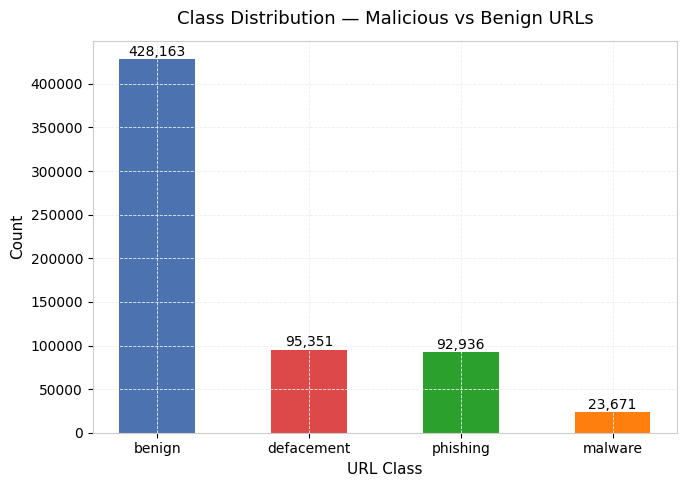

In [ ]:
# EDA Visualization 1: Class Distribution
class_counts = df_raw[TARGET_COL].value_counts()

fig, ax = plt.subplots(figsize=(7, 5))
colors = ['#4C72B0', '#DD4949', '#2ca02c', '#ff7f0e'][:len(class_counts)]
bars = ax.bar(class_counts.index.astype(str), class_counts.values, color=colors, edgecolor='none', width=0.5)
for bar, val in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
            f'{val:,}', ha='center', va='bottom', fontsize=10)
ax.set_title('Class Distribution — Malicious vs Benign URLs', pad=12)
ax.set_xlabel('URL Class')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('class_distribution.png', bbox_inches='tight')
plt.show()

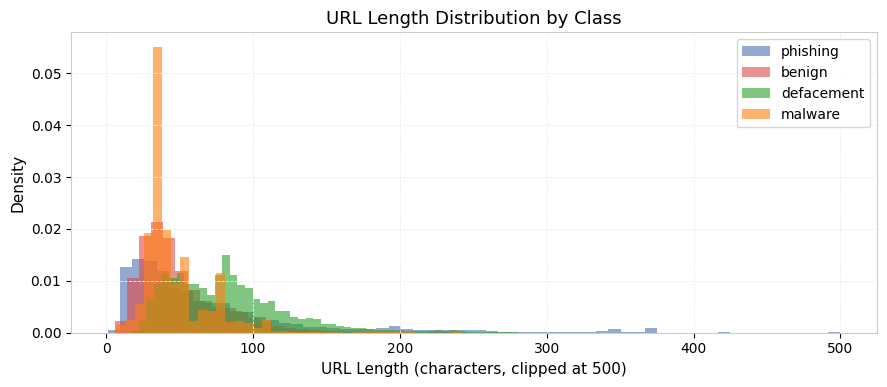

In [ ]:
# EDA Visualization 2: URL Length Distribution by Class
df_raw['_url_len_temp'] = df_raw[URL_COL].astype(str).apply(len)

fig, ax = plt.subplots(figsize=(9, 4))
for cls, color in zip(df_raw[TARGET_COL].unique(), ['#4C72B0', '#DD4949', '#2ca02c', '#ff7f0e']):
    subset = df_raw[df_raw[TARGET_COL] == cls]['_url_len_temp']
    ax.hist(subset.clip(upper=500), bins=60, alpha=0.6, color=color, label=str(cls), density=True)
ax.set_xlabel('URL Length (characters, clipped at 500)')
ax.set_ylabel('Density')
ax.set_title('URL Length Distribution by Class')
ax.legend()
plt.tight_layout()
plt.savefig('url_length_distribution.png', bbox_inches='tight')
plt.show()

df_raw.drop(columns=['_url_len_temp'], inplace=True)